In [1]:
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
RANDOM_SEED = 0
# ---------------------------
# Baseline samplers
# ---------------------------
from scipy.stats import qmc
def sample_random(n: int, seed: int) -> np.ndarray:
    r = np.random.RandomState(seed)
    return DOMAIN[0] + r.rand(n,1) * (DOMAIN[1] - DOMAIN[0])

def sample_sobol(n: int, seed: int) -> np.ndarray:
    eng = qmc.Sobol(d=1, scramble=True, seed=seed)
    m = int(np.ceil(np.log2(max((2,n)))))
    pts = eng.random_base2(m=m)[:n,:]
    return DOMAIN[0] + pts * (DOMAIN[1] - DOMAIN[0])

def sample_lhs(n: int, seed: int) -> np.ndarray:
    eng = qmc.LatinHypercube(d=1, seed=seed)
    pts = eng.random(n)
    return DOMAIN[0] + pts * (DOMAIN[1] - DOMAIN[0])

def sample_grid(n: int, seed: int):
    return np.linspace(DOMAIN[0], DOMAIN[1], n).reshape((-1,1))

# ---------------------------
# Bayesian EI sampler
# ---------------------------
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from scipy.stats import norm

def fit_gp_fast(X, y):
    kernel = C(1.0)*RBF(length_scale=0.25) + WhiteKernel(noise_level=1e-6)
    gp = GaussianProcessRegressor(kernel=kernel, optimizer=None, alpha=0.0, normalize_y=True, random_state=0)
    gp.fit(X, y.ravel())
    return gp

def expected_improvement(Xgrid, gp, y_best, xi=0.01):
    mu, sigma = gp.predict(Xcand, return_std=True)
    sigma = np.maximum(sigma, 1e-12)
    imp = y_best - mu - xi
    Z = imp / sigma
    return imp * norm.cdf(Z) + sigma * norm.pdf(Z)

def sample_bayesian_ei(n: int, seed: int, init_n: int = 4) -> np.ndarray:
    X = sample_sobol(init_n, seed); y = f(X.ravel())[:,None]
    gp = fit_gp_fast(X, y)
    grid = np.linspace(DOMAIN[0], DOMAIN[1], DENSE_BUDGET).reshape(-1,1)
    while X.shape[0] < n:
        ei = expected_improvement(grid, gp, np.min(y), xi=0.01)
        idx = int(np.argmax(ei))
        x_next = float(grid[idx,0])
        if np.any(np.isclose(X.ravel(), x_next, atol=1e-12)):
            x_next = float((x_next + np.random.uniform(-1e-3, 1e-3)) % DOMAIN[1])
        X = np.vstack([X, [[x_next]]])
        y = np.vstack([y, [[f(np.array([x_next]))[0]]]])
        gp = fit_gp_fast(X, y)
    return X

# ---------------------------
# Models: GP, Improved MLP (Fourier ensemble), RF
# ---------------------------
import torch
import torch.nn as nn

from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

def fit_rf(X, y):
    rf = RandomForestRegressor(n_estimators=350, random_state=RANDOM_SEED)
    rf.fit(X, y.ravel()); return rf

def fourier_features(x_raw: np.ndarray, K: int = 12) -> np.ndarray:
    a, b = DOMAIN
    x = (x_raw - a) / (b - a)
    feats = [x, x**2, x**3, x**4]
    for k in range(1, K+1):
        feats.append(np.sin(2*np.pi*k*x))
        feats.append(np.cos(2*np.pi*k*x))
    return np.column_stack(feats)

# --- 4. Define the MLP Model ---
class TorchMLP(nn.Module):
    def __init__(self):
        super(TorchMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)

class ImprovedMLP:
    def __init__(self, K=12, n_ensemble=5, seed=RANDOM_SEED):
        self.K = K
        self.n_ens = n_ensemble
        self.seed = seed
        self.scaler_X = StandardScaler(with_mean=False)
        self.scaler_y = StandardScaler()
        self.models = []

    def fit(self, X, y):
        Phi = fourier_features(X, self.K)
        self.scaler_X.fit(Phi)
        Phi_s = self.scaler_X.transform(Phi)
        y_s = self.scaler_y.fit_transform(y.reshape(-1,1)).ravel()
        self.models = []
        for i in range(self.n_ens):
            mlp = MLPRegressor(hidden_layer_sizes=(256,256,256), activation="relu",
                               solver="adam", learning_rate_init=1.5e-3, alpha=1e-4,
                               max_iter=9000, early_stopping=True, n_iter_no_change=500,
                               validation_fraction=0.2, random_state=self.seed + i)
            mlp.fit(Phi_s, y_s)
            self.models.append(mlp)
        return self

    def predict(self, Xq, return_std=False):
        Phi_q = fourier_features(Xq, self.K)
        Phi_qs = self.scaler_X.transform(Phi_q)
        preds = np.column_stack([m.predict(Phi_qs) for m in self.models])
        preds = self.scaler_y.inverse_transform(preds)
        yq_m = preds.mean(axis=1, keepdims=True)
        yq_s = preds.std(axis=1, keepdims=True)
        
        yqm = yq_m.ravel() # self.scaler_y.inverse_transform(yq_m).ravel()
        yqs = yq_s.ravel() #self.scaler_y.inverse_transform(yq_s).ravel()
        
        if return_std:
            return yqm, yqs
        else:
            return yqm
    
# --- 4. Define the MLP Model and Wrapper ---
class ForresterMLP(nn.Module):
    def __init__(self):
        super(ForresterMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        return self.network(x)

class MLPWrapper:
    def __init__(self, num_epochs=5000, lr=0.001):
        self.model = ForresterMLP()
        self.num_epochs = num_epochs
        self.lr = lr

    def fit(self, x_train, y_train):
        """Trains the MLP model on the provided data."""
        x_train_tensor = torch.from_numpy(x_train).float().view(-1, 1)
        y_train_tensor = torch.from_numpy(y_train).float().view(-1, 1)
        
        loss_function = nn.MSELoss()
        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)

        self.model.train()
        for epoch in range(self.num_epochs):
            y_pred_train = self.model(x_train_tensor)
            loss = loss_function(y_pred_train, y_train_tensor)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        return self

    def predict(self, x_test):
        """Makes predictions on new data."""
        x_test_tensor = torch.from_numpy(x_test).float().view(-1, 1)
        self.model.eval()
        with torch.no_grad():
            return self.model(x_test_tensor).numpy().flatten()


def fit_mlp(x_train, y_train):
    """A simple wrapper function to fit the MLP model."""
    return MLPWrapper().fit(x_train, y_train)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pyomo.environ import ConcreteModel, Var, value

from abc import ABC, abstractmethod
from pyomo.environ import Param, RangeSet
from pyomo.environ import ConcreteModel, Var, sin as pysin, sqrt as pysqrt, exp as pyexp
from pyomo.environ import cos as pycos
from pyomo.contrib.mcpp.pyomo_mcpp import McCormick

class Function2D(ABC):
    def __init__(self, envelope_samples=10):
        self.envelope_samples = envelope_samples

    @abstractmethod
    def f(self, x):
        pass

    @abstractmethod
    def f_mccormick(self, a1, b1, a2, b2):
        pass

    def envelope_interval(self, a1, b1, a2, b2):
        """
        Estimate McCormick envelope over [a1, b1] x [a2, b2] using a regular grid
        """
        mc, m = self.f_mccormick(a1, b1, a2, b2)
        x1_samples = np.linspace(a1, b1, self.envelope_samples)
        x2_samples = np.linspace(a2, b2, self.envelope_samples)
        xx1, xx2 = np.meshgrid(x1_samples, x2_samples)
        gap = []
        lower = []
        upper = []
        x_samples = []
        for xi1, xi2 in zip(xx1.flatten(), xx2.flatten()):
            m.x1.set_value(xi1)
            m.x2.set_value(xi2)
            mc.changePoint(m.x1, xi1)
            mc.changePoint(m.x2, xi2)
            luv = mc.concave()
            llo = mc.convex()
            upper.append(luv)
            lower.append(llo)
            gap.append(luv - llo)
            x_samples.append([xi1, xi2])
        return np.array(x_samples), np.array(lower), np.array(upper), np.array(gap)

    def envelope_interval_points(self, a1, b1, a2, b2, xs):
        """
        Estimate McCormick envelope at specified xs points, where xs is (N, 2)
        """
        mc, m = self.f_mccormick(a1, b1, a2, b2)
        def get_upper_lower(m, mc, xi):
            m.x1.set_value(xi[0])
            m.x2.set_value(xi[1])
            mc.changePoint(m.x1, xi[0])
            mc.changePoint(m.x2, xi[1])
            return mc.concave(), mc.convex()
        upper_lower = np.array([get_upper_lower(m, mc, xi) for xi in xs])
        gap = upper_lower[:, 0] - upper_lower[:, 1]
        return xs, upper_lower[:, 1], upper_lower[:, 0], gap


class Langermann2D(Function2D):
    def __init__(self):
        super().__init__()
        self.a = np.array([3.0, 5.0, 2.0, 1.0, 7.0])
        self.c = np.array([1.0, 2.0, 5.0, 2.0, 3.0])

    def f(self, x):
        x = np.asarray(x, dtype=float)
        x1, x2 = x[..., 0], x[..., 1]
        s = (x1[..., None] - self.a) ** 2 + (x2[..., None] - self.a) ** 2
        terms = self.c * np.exp(-s / np.pi) * np.cos(np.pi * s)
        y = terms.sum(axis=-1)
        return y.item() if np.ndim(y) == 0 else y

    def f_mccormick(self, a1, b1, a2, b2):
        EPS = 1e-8
        m = ConcreteModel()
        m.I = RangeSet(len(self.a))
        m.x1 = Var(bounds=(a1, b1))
        m.x2 = Var(bounds=(a2, b2))
        m.A = Param(m.I, initialize={i + 1: float(self.a[i]) for i in range(len(self.a))})
        m.C = Param(m.I, initialize={i + 1: float(self.c[i]) for i in range(len(self.c))})

        # The Pyomo expression for the 2D Langermann sum
        expr = sum(
            m.C[i] *
            pyexp(-((m.x1 - m.A[i])**2 + (m.x2 - m.A[i])**2 + EPS) / float(np.pi)) *
            pycos(float(np.pi) * ((m.x1 - m.A[i])**2 + (m.x2 - m.A[i])**2 + EPS))
            for i in m.I
        )
        mc = McCormick(expr)
        return mc, m

    

In [8]:
from functions.function import Forrester, Schwefel, Higdon, GrammacyLee, Sigmoid, Ackley, Langermann, Griewank

from interval_builder import IntervalBuilder
from envelope_builder import piecewise_envelopes
from samplers.adaptive_sampler import AdaptiveSampler

In [9]:
FUNCTIONS = {
    "Ackley": {"domain": [-32.768, 32.768], 'f': Ackley},
#     "Ackley": {"domain": [-6, 6], 'f': Ackley},
    "Schwefel": {'domain':[-500, 500], 'f': Schwefel},
    "Sigmoid": {'domain': [-6, 6], 'f': Sigmoid},
    "GramacyLee": {'domain':[0.5, 2.5], 'f': GrammacyLee},
    "Higdon": {'domain': [0, 10], 'f': Higdon},
    "Forrester": {'domain': [0, 2.5], 'f': Forrester},
    "Langermann": {'domain': [-10, 20], 'f': Langermann},
    "Griewank": {'domain': [-50, 50], 'f': Griewank},
}

selection = 'Langermann'
OVERALL_BUDGET = 200
sampling_budget = 0.2

BUDGET = int(OVERALL_BUDGET * sampling_budget)
REFINING = int(OVERALL_BUDGET * (1 - sampling_budget))

# BUDGET = 100
GRID_EVAL = 10

func = f2d #FUNCTIONS[selection]['f']()
DOMAIN = FUNCTIONS[selection]['domain']
# DOMAIN[0] *= 2
# DOMAIN[1] *= 2
# DOMAIN = (-30.0, 0.0)
# Minimum samples per gap
DOMAIN_SPLITS_PC = 0.3
DOMAIN_SPLITS = 10 #int(np.ceil(1/DOMAIN_SPLITS_PC))

MIN_SAMPLE_PC = 0.01
MIN_SAMPLES = int(BUDGET * MIN_SAMPLE_PC)
MIN_SAMPLES = MIN_SAMPLES if MIN_SAMPLES else 1


CONFIG = {
    "n_samples": 15,
#     "max_envelope_size": 0.2,
    "max_envelope_size": 1.0,
    'max_gap': 0.5,
    'seed': 42,
    'intervals': {
        'a': DOMAIN[0],
        'b': DOMAIN[1],
    },
    "budget": BUDGET,
}
f = f2d.f

In [62]:
OVERALL_BUDGET = 200
sampling_budget = 0.6

BUDGET = OVERALL_BUDGET * sampling_budget
REFINING = OVERALL_BUDGET * (1 - sampling_budget)

def method0_uncertanity2d(func, sample_coarse=True, return_domains=True, mccormick_sampling=False):
    sampler = AdaptiveSampler(func, BUDGET, False)
    breakpoints = np.linspace(DOMAIN[0], DOMAIN[1], DOMAIN_SPLITS + 1)
#     Xgrid = np.linspace(DOMAIN[0], DOMAIN[1], DOMAIN_SPLITS)
#     Ygrid = func.f(Xgrid)

#     breakpoints = [DOMAIN[0], DOMAIN[1]]

    domains = []
    gaps = []
    for i in range(len(breakpoints) - 1):
        for j in range(len(breakpoints) - 1):
            a1, b1 = breakpoints[i], breakpoints[i + 1]
            a2, b2 = breakpoints[j], breakpoints[j + 1]
            print(a1,b1,a2,b2) 
            mc, m = func.f_mccormick(a1, b1, a2, b2)
            if sample_coarse:
                lb, ub = compute_bounds_on_expr(mc.pyomo_expr)
                gap = [ub - lb]
            else:
                _, _, _, gap = func.envelope_interval(a1, b1, a2, b2)
            domains.append((a1, b1, a2, b2))
            gaps.append(max(gap))
        
    sample_dist = allocate_samples(gaps, BUDGET, MIN_SAMPLES)
    print('Sample Allocations ({}): '.format(sum(sample_dist)), sample_dist)
    sampled_x = []
    for idx in range(len(domains)):
        a1,b1,a2,b2 = domains[idx]
        s = sample_dist[idx]
        if mccormick_sampling:
            samples, _ = sampler.sample_points(domain=domains[idx], points_n=s)
        else:
            if idx > 0:
                xss = np.linspace(a1, b1, s + 1)[1:]
                yss = np.linspace(a2, b2, s+ 1)[1:]
                samples = list(zip(xss, yss))
            else:
                xss = np.linspace(a1, b1, s)
                yss = np.linspace(a2, b2, s)
                samples = list(zip(xss, yss))
        sampled_x.extend(samples)
    sampled_x.sort()
    sampled_x = np.array(sampled_x)
    sampled_y = func.f(sampled_x)
    
    if return_domains:
        return sampled_x, sampled_y, domains, gaps
    else:
        return sampled_x, sampled_y

from typing import List

def allocate_samples(weights: List[float], total_samples: int, min_per_gap: int) -> List[int]:
    """
    Allocate total_samples across gaps proportionally to weights,
    ensuring at least min_per_gap samples for each gap.
    
    Args:
        weights (List[float]): List of weights (e.g., gap sizes).
        total_samples (int): Total number of samples to allocate.
        min_per_gap (int): Minimum samples each gap must receive.
        
    Returns:
        List[int]: Final allocation of samples per gap.
    """
    n = len(weights)
    # Step 1: Assign minimum to each gap
    base_alloc = [min_per_gap] * n
    remaining = total_samples - n * min_per_gap
    print(n)
    print('Base Alloc : ', min_per_gap* n)
    print('Remaining : ', remaining)
    if remaining < 0:
        raise ValueError("Not enough samples to satisfy minimum requirement for all gaps.")
    
    # Step 2: Normalize weights
    total_weight = sum(weights)
    proportions = [w / total_weight for w in weights]
    
    # Step 3: Proportional allocation
    proportional_alloc = [remaining * p for p in proportions]
    
    # Step 4: Combine and round
    final_alloc = [base + int(round(prop)) for base, prop in zip(base_alloc, proportional_alloc)]
    
    # Step 5: Adjust to ensure sum matches total_samples
    diff = total_samples - sum(final_alloc)
    
    # Distribute remainder (if rounding caused mismatch)
    i = 0
    while diff != 0:
        if diff > 0:
            final_alloc[i % n] += 1
            diff -= 1
        else:
            if final_alloc[i % n] > min_per_gap:
                final_alloc[i % n] -= 1
                diff += 1
        i += 1
    
    return final_alloc

import bisect

def assign_domains(points, domains):
    boundaries = [d[1] for d in domains]
    result = []
    for p in points:
        idx = bisect.bisect_left(boundaries, p)
        if idx == 0:
            d = domains[0]
            if d[0] <= p <= d[1]:
                result.append(idx)
            else:
                result.append(-1)
        elif idx < len(domains):
            d = domains[idx]
            if d[0] < p <= d[1]:
                result.append(idx)
            else:
                result.append(-1)
        else:
            result.append(-1)
    return np.array(result)


def assign_domains_2d(points, domains):
    result = []
    for p in points:
        found = -1
        for idx, d in enumerate(domains):
            x_low, x_high = d[0]
            y_low, y_high = d[1]
            if x_low <= p[0] <= x_high and y_low <= p[1] <= y_high:
                found = idx
                break
        result.append(found)
    return np.array(result)


In [14]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C

def fit_gp_2d(X, y):
    # Solid default kernel: Matern + Constant + low-noise white kernel
    kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=1.0, nu=2.5) + WhiteKernel(1e-6)
    gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=3, random_state=0)
    gp.fit(X, y)
    return gp

In [15]:
from scipy.stats import norm

def expected_improvement(mu, std, y_opt=0.0, xi=0.01):
    values = np.zeros_like(mu, dtype=np.float64)
    mask = std > 0
    improve = y_opt - xi - mu[mask]
    scaled = improve / std[mask]
    cdf = norm.cdf(scaled)
    pdf = norm.pdf(scaled)
    exploit = improve * cdf
    explore = std[mask] * pdf
    values[mask] = exploit + explore

    return values

In [16]:
import os
from tqdm import tqdm
from sklearn.metrics import mean_absolute_percentage_error
from typing import List, Tuple, Callable, Dict

In [63]:
# DOMAIN is still [lo, hi] scalars — same as 1D.
# For 2D we treat both axes as having the same domain bounds,
# i.e. the domain is [lo, hi] x [lo, hi].

def sample_random_2d(n: int, seed: int) -> np.ndarray:
    r = np.random.RandomState(seed)
    pts = r.rand(n, 2)
    return DOMAIN[0] + pts * (DOMAIN[1] - DOMAIN[0])

def sample_sobol_2d(n: int, seed: int) -> np.ndarray:
    eng = qmc.Sobol(d=2, scramble=True, seed=seed)
    m = int(np.ceil(np.log2(max(2, n))))
    pts = eng.random_base2(m=m)[:n, :]          # (n, 2) in [0,1)^2
    return DOMAIN[0] + pts * (DOMAIN[1] - DOMAIN[0])

def sample_lhs_2d(n: int, seed: int) -> np.ndarray:
    eng = qmc.LatinHypercube(d=2, seed=seed)
    pts = eng.random(n)                         # (n, 2) in [0,1)^2
    return DOMAIN[0] + pts * (DOMAIN[1] - DOMAIN[0])

def sample_grid_2d(n: int, seed: int) -> np.ndarray:
    k = int(np.ceil(np.sqrt(n)))
    g = np.linspace(DOMAIN[0], DOMAIN[1], k)   # same bounds on both axes
    xx1, xx2 = np.meshgrid(g, g)
    return np.column_stack([xx1.ravel(), xx2.ravel()])


def method_0a_2d(func: Function2D,
                 sample_coarse: bool = False,
                 return_domains: bool = False):

    def compute_gap(a1, b1, a2, b2):
        mc, m = func.f_mccormick(a1, b1, a2, b2)
        if sample_coarse:
            lb, ub = compute_bounds_on_expr(mc.pyomo_expr)
            return float(ub - lb)
        else:
            _, _, _, gap = func.envelope_interval(a1, b1, a2, b2)
            return float(max(gap))

    # Single starting rectangle: [lo,hi] x [lo,hi]
    lo, hi = float(DOMAIN[0]), float(DOMAIN[1])

    domains: list = [(lo, hi, lo, hi)]
    gaps:    list = [compute_gap(lo, hi, lo, hi)]

    target = BUDGET*1.0 - 3   # net +3 per split (1 → 4 children)

    while len(domains) < target:
        domain_idx = int(np.argmax(gaps))
        a1, b1, a2, b2 = domains.pop(domain_idx)
        gaps.pop(domain_idx)

        mid1 = (a1 + b1) / 2.0
        mid2 = (a2 + b2) / 2.0

        children = [
            (a1,   mid1, a2,   mid2),
            (mid1, b1,   a2,   mid2),
            (a1,   mid1, mid2, b2  ),
            (mid1, b1,   mid2, b2  ),
        ]

        for child in children:
            domains.append(child)
            gaps.append(compute_gap(*child))

    # Collect unique corners from all surviving rectangles
    corners = []
    for (a1, b1, a2, b2) in domains:
        corners.extend([[a1, a2], [a1, b2], [b1, a2], [b1, b2]])

    sampled_x = np.unique(np.array(corners), axis=0)
    sampled_x = sampled_x[np.lexsort((sampled_x[:, 1], sampled_x[:, 0]))]
    sampled_y = func.f(sampled_x)

    if return_domains:
        return sampled_x, sampled_y, domains, gaps
    return sampled_x, sampled_y

In [64]:
x,y = method_0a_2d(func)

/var/folders/c3/1z16953x2r900q_snc40rgjc0000gn/T/ipykernel_42934/3465741938.py:88: DeprecationWarning:

Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.



In [19]:
rmse: Dict[Tuple[str,str], float] = {}
mape: Dict[Tuple[str,str], float] = {}
samples: Dict[str, np.ndarray] = {}  # name -> (n,2)
preds:   Dict[Tuple[str,str], np.ndarray] = {}
stds:   Dict[Tuple[str,str], np.ndarray] = {}

In [65]:
func = f2d

In [67]:
OVERALL_BUDGET  = 200
sampling_budget = 0.6
BUDGET   = int(OVERALL_BUDGET * sampling_budget)   # 180
REFINING = int(OVERALL_BUDGET * (1 - sampling_budget))  # 120

BUDGET = 200
X, y, domains, gaps = method0_uncertanity2d(func, sample_coarse=False, mccormick_sampling=False)

X_og = X.copy()
y_og = y.copy()

f = func.f

# ── Filtered test set based on high-gap domains ───────────────
n_test = 100
x1_test = np.linspace(DOMAIN[0], DOMAIN[1], n_test)
x2_test = np.linspace(DOMAIN[0], DOMAIN[1], n_test)
xx1, xx2 = np.meshgrid(x1_test, x2_test)
X_test = np.column_stack([xx1.ravel(), xx2.ravel()])
y_test = f(X_test)

sample_dist = allocate_samples(gaps, 200, 1)
mask = np.array(sample_dist) > 2
final_mask = np.zeros(X_test.shape[0], dtype=bool)

# FIX 2: correct domain index unpacking
for d in np.array(domains)[mask]:
    x1_low, x1_high, x2_low, x2_high = d[0], d[1], d[2], d[3]
    in_domain = (
        (X_test[:, 0] >= x1_low)  & (X_test[:, 0] <= x1_high) &
        (X_test[:, 1] >= x2_low)  & (X_test[:, 1] <= x2_high)
    )
    final_mask |= in_domain

X_test_uf = X_test.copy()
y_test_uf = f(X_test)

X_test = X_test[final_mask]
y_test  = f(X_test)

# ── Evaluation grid ───────────────────────────────────────────
n_grid = 500
x1_grid = np.linspace(DOMAIN[0], DOMAIN[1], n_grid)
x2_grid = np.linspace(DOMAIN[0], DOMAIN[1], n_grid)
xx1, xx2 = np.meshgrid(x1_grid, x2_grid)
X_grid      = np.column_stack([xx1.ravel(), xx2.ravel()])
y_grid_true = f(X_grid)

# FIX 1: no reshape — pass domains directly
X_domains      = assign_domains_2d(X_grid, np.array(domains).reshape((-1,2,2)))
X_grid_gaps    = np.array(gaps)[X_domains.ravel()]
domain_weights = (X_grid_gaps / sum(gaps)) * 100

# ── Strategy loop ─────────────────────────────────────────────
n_add = REFINING
xi    = 0.01

np.random.seed(RANDOM_SEED)

strategies: List[Tuple[str, Callable[[int, int], np.ndarray]]] = [
    ("Sobol",                          sample_sobol_2d),
    ("LHS",                            sample_lhs_2d),
    ("Grid",                           sample_grid_2d),
    ("Approach B",                     lambda n, seed: method_0a_2d(func)),
    ("Approach A - Uniform Sampling",  lambda n, seed: method0_uncertanity2d(
        func, sample_coarse=False, return_domains=False, mccormick_sampling=False)),
]

outputs = {}
rmse:    Dict[Tuple[str, str], float]      = {}
mape:    Dict[Tuple[str, str], float]      = {}
samples: Dict[str, np.ndarray]             = {}
preds:   Dict[Tuple[str, str], np.ndarray] = {}
stds:    Dict[Tuple[str, str], np.ndarray] = {}

RUN_BUDGET = 200   # FIX 3: don't overwrite global BUDGET

for strategy, gen in strategies:
    print('Strategy:', strategy, RUN_BUDGET)
    if strategy in ['Sobol', 'LHS', 'Grid']:
        X = gen(RUN_BUDGET, RANDOM_SEED)
        y = func.f(X)
    else:
        X, y = gen(RUN_BUDGET, RANDOM_SEED)
    print('Training Surrogates\n')
    for surrogate in ['NN', 'GP']:
        if surrogate != 'NN':
            ensemble = fit_gp_2d(X, y)
        else:
            ensemble = ImprovedMLP(K=2, n_ensemble=5)
            ensemble.fit(X, y)

        mu, std = ensemble.predict(X_test, return_std=True)

        preds[(strategy, surrogate)] = (mu, std)
        rmse[(strategy, surrogate)]  = float(np.sqrt(mean_squared_error(y_test, np.array(mu).ravel())))
        mape[(strategy, surrogate)]  = float(mean_absolute_percentage_error(y_test, np.array(mu).ravel()))

    samples[strategy] = (X.copy(), y.copy())
    outputs[strategy] = (preds, rmse, mape, samples)


-10.0 -7.0 -10.0 -7.0
-10.0 -7.0 -7.0 -4.0
-10.0 -7.0 -4.0 -1.0
-10.0 -7.0 -1.0 2.0


/var/folders/c3/1z16953x2r900q_snc40rgjc0000gn/T/ipykernel_42934/3465741938.py:88: DeprecationWarning:

Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.



-10.0 -7.0 2.0 5.0
-10.0 -7.0 5.0 8.0
-10.0 -7.0 8.0 11.0
-10.0 -7.0 11.0 14.0
-10.0 -7.0 14.0 17.0
-10.0 -7.0 17.0 20.0
-7.0 -4.0 -10.0 -7.0
-7.0 -4.0 -7.0 -4.0
-7.0 -4.0 -4.0 -1.0
-7.0 -4.0 -1.0 2.0
-7.0 -4.0 2.0 5.0
-7.0 -4.0 5.0 8.0
-7.0 -4.0 8.0 11.0
-7.0 -4.0 11.0 14.0
-7.0 -4.0 14.0 17.0
-7.0 -4.0 17.0 20.0
-4.0 -1.0 -10.0 -7.0
-4.0 -1.0 -7.0 -4.0
-4.0 -1.0 -4.0 -1.0
-4.0 -1.0 -1.0 2.0
-4.0 -1.0 2.0 5.0
-4.0 -1.0 5.0 8.0
-4.0 -1.0 8.0 11.0
-4.0 -1.0 11.0 14.0
-4.0 -1.0 14.0 17.0
-4.0 -1.0 17.0 20.0
-1.0 2.0 -10.0 -7.0
-1.0 2.0 -7.0 -4.0
-1.0 2.0 -4.0 -1.0
-1.0 2.0 -1.0 2.0
-1.0 2.0 2.0 5.0
-1.0 2.0 5.0 8.0
-1.0 2.0 8.0 11.0
-1.0 2.0 11.0 14.0
-1.0 2.0 14.0 17.0
-1.0 2.0 17.0 20.0
2.0 5.0 -10.0 -7.0
2.0 5.0 -7.0 -4.0
2.0 5.0 -4.0 -1.0
2.0 5.0 -1.0 2.0
2.0 5.0 2.0 5.0
2.0 5.0 5.0 8.0
2.0 5.0 8.0 11.0
2.0 5.0 11.0 14.0
2.0 5.0 14.0 17.0
2.0 5.0 17.0 20.0
5.0 8.0 -10.0 -7.0
5.0 8.0 -7.0 -4.0
5.0 8.0 -4.0 -1.0
5.0 8.0 -1.0 2.0
5.0 8.0 2.0 5.0
5.0 8.0 5.0 8.0
5.0 8.0 8.0 11.0
5.0 8.0 

/opt/anaconda3/envs/thesis/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning:

The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.



Strategy: LHS 200
Training Surrogates



...

/opt/anaconda3/envs/thesis/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning:

The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.



Strategy: Approach A - Uniform Sampling 200
-10.0 -7.0 -10.0 -7.0
-10.0 -7.0 -7.0 -4.0


/var/folders/c3/1z16953x2r900q_snc40rgjc0000gn/T/ipykernel_42934/3465741938.py:88: DeprecationWarning:

Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.



-10.0 -7.0 -4.0 -1.0
-10.0 -7.0 -1.0 2.0
-10.0 -7.0 2.0 5.0
-10.0 -7.0 5.0 8.0
-10.0 -7.0 8.0 11.0
-10.0 -7.0 11.0 14.0
-10.0 -7.0 14.0 17.0
-10.0 -7.0 17.0 20.0
-7.0 -4.0 -10.0 -7.0
-7.0 -4.0 -7.0 -4.0
-7.0 -4.0 -4.0 -1.0
-7.0 -4.0 -1.0 2.0
-7.0 -4.0 2.0 5.0
-7.0 -4.0 5.0 8.0
-7.0 -4.0 8.0 11.0
-7.0 -4.0 11.0 14.0
-7.0 -4.0 14.0 17.0
-7.0 -4.0 17.0 20.0
-4.0 -1.0 -10.0 -7.0
-4.0 -1.0 -7.0 -4.0
-4.0 -1.0 -4.0 -1.0
-4.0 -1.0 -1.0 2.0
-4.0 -1.0 2.0 5.0
-4.0 -1.0 5.0 8.0
-4.0 -1.0 8.0 11.0
-4.0 -1.0 11.0 14.0
-4.0 -1.0 14.0 17.0
-4.0 -1.0 17.0 20.0
-1.0 2.0 -10.0 -7.0
-1.0 2.0 -7.0 -4.0
-1.0 2.0 -4.0 -1.0
-1.0 2.0 -1.0 2.0
-1.0 2.0 2.0 5.0
-1.0 2.0 5.0 8.0
-1.0 2.0 8.0 11.0
-1.0 2.0 11.0 14.0
-1.0 2.0 14.0 17.0
-1.0 2.0 17.0 20.0
2.0 5.0 -10.0 -7.0
2.0 5.0 -7.0 -4.0
2.0 5.0 -4.0 -1.0
2.0 5.0 -1.0 2.0
2.0 5.0 2.0 5.0
2.0 5.0 5.0 8.0
2.0 5.0 8.0 11.0
2.0 5.0 11.0 14.0
2.0 5.0 14.0 17.0
2.0 5.0 17.0 20.0
5.0 8.0 -10.0 -7.0
5.0 8.0 -7.0 -4.0
5.0 8.0 -4.0 -1.0
5.0 8.0 -1.0 2.0
5.0 8.0 2.0 5.0


/opt/anaconda3/envs/thesis/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning:

The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.



In [68]:

# ── Config ────────────────────────────────────────────────────
OVERALL_BUDGET  = 200
sampling_budget = 0.6
BUDGET   = int(OVERALL_BUDGET * sampling_budget)   # 180
REFINING = int(OVERALL_BUDGET * (1 - sampling_budget))  # 120

surrogate = 'GP'
experiment_name = '{}+STD + warm_start - {}'.format(surrogate, BUDGET)
output_dir      = './plots/2D/it1-13.02.26/{}'.format(experiment_name)
output_dir_plot = '{}/sampling/'.format(output_dir)
output_dir_ei   = '{}/ei/'.format(output_dir)
os.makedirs(output_dir_plot, exist_ok=True)
os.makedirs(output_dir_ei,   exist_ok=True)

# ── Initial sampling ──────────────────────────────────────────
X, y, domains, gaps = method0_uncertanity2d(func, sample_coarse=False, mccormick_sampling=False)

X_og = X.copy()
y_og = y.copy()
f    = func.f

# ── Filtered test set (high-gap domains only) ─────────────────
n_test = 100
xx1, xx2 = np.meshgrid(
    np.linspace(DOMAIN[0], DOMAIN[1], n_test),
    np.linspace(DOMAIN[0], DOMAIN[1], n_test)
)
X_test = np.column_stack([xx1.ravel(), xx2.ravel()])
y_test = f(X_test)

sample_dist = allocate_samples(gaps, 200, 1)
mask        = np.array(sample_dist) > 2
final_mask  = np.zeros(X_test.shape[0], dtype=bool)

# FIX 1: correct domain index unpacking — flat (x1_low, x1_high, x2_low, x2_high)
for d in np.array(domains)[mask]:
    x1_low, x1_high, x2_low, x2_high = d[0], d[1], d[2], d[3]
    in_domain = (
        (X_test[:, 0] >= x1_low) & (X_test[:, 0] <= x1_high) &
        (X_test[:, 1] >= x2_low) & (X_test[:, 1] <= x2_high)
    )
    final_mask |= in_domain

X_test_uf = X_test.copy()
y_test_uf = f(X_test)

X_test = X_test[final_mask]
y_test = f(X_test)

# ── Evaluation grid ───────────────────────────────────────────
n_grid = 300
xx1, xx2 = np.meshgrid(
    np.linspace(DOMAIN[0], DOMAIN[1], n_grid),
    np.linspace(DOMAIN[0], DOMAIN[1], n_grid)
)
X_grid      = np.column_stack([xx1.ravel(), xx2.ravel()])
y_grid_true = f(X_grid)

# FIX 2: remove .reshape((-1,2,2)) — pass flat domains directly
X_domains      = assign_domains_2d(X_grid, np.array(domains).reshape((-1,2,2)))
X_grid_gaps    = np.array(gaps)[X_domains.ravel()]
domain_weights = (X_grid_gaps / sum(gaps)) * 100

# ── Duplicate check: use 2D distance not 1D abs ───────────────
def is_duplicate_2d(X_existing, x_new, tol_frac=0.01):
    """Return True if x_new is within tol of any existing point."""
    tol = (DOMAIN[1] - DOMAIN[0]) * tol_frac
    dists = np.linalg.norm(X_existing - x_new, axis=1)   # FIX 3: Euclidean distance
    return np.min(dists) < tol

# ── Output containers ─────────────────────────────────────────
# outputs = {}
# rmse:    Dict[Tuple[str, str], float]       = {}
# mape:    Dict[Tuple[str, str], float]       = {}
# samples: Dict[str, np.ndarray]              = {}
# preds:   Dict[Tuple[str, str], np.ndarray]  = {}

n_add = REFINING
xi    = 0.01

strategies = [
    ('EI',
     lambda mu, std, f_best, xi: expected_improvement(mu, std, f_best, xi=xi)),
    ('EI (Std * domain_weights)',
     lambda mu, std, f_best, xi: expected_improvement(mu, std * domain_weights, f_best, xi=xi)),
    ('STD',
     lambda mu, std, f_best, xi: std),
    ('STD * domain_weights',
     lambda mu, std, f_best, xi: std * domain_weights),
]

for strategy, ei_func in strategies:
    print('Strategy:', strategy)
    X = X_og.copy()
    y = y_og.copy()

    # ── Refinement loop ───────────────────────────────────────
    for t in tqdm(range(int(n_add))):
        if surrogate != 'NN':
            ensemble = fit_gp_2d(X, y)
        else:
            ensemble = ImprovedMLP(K=2, n_ensemble=5)   # FIX 4: re-init NN each iter
            ensemble.fit(X, y)

        mu, std = ensemble.predict(X_grid, return_std=True)
        f_best  = np.min(y)

        ei  = ei_func(mu, std, f_best, xi)
        idx = int(np.argmax(ei))
        x_next = X_grid[idx: idx + 1]

        # FIX 3: use Euclidean distance for duplicate check in 2D
        tries    = 0
        ei_copy  = ei.copy()
        while is_duplicate_2d(X, x_next) and tries < 10:
            ei_copy[idx] = -np.inf
            idx    = int(np.argmax(ei_copy))
            x_next = X_grid[idx: idx + 1]
            tries += 1

        y_next = f(x_next)
        X = np.vstack([X, x_next])
        y = np.concatenate([y, y_next])

    # ── Evaluate GP after refinement ──────────────────────────
    mu, std = ensemble.predict(X_test, return_std=True)
    mu_uf, stduf = ensemble.predict(X_test_uf, return_std=True)
    
    preds[(strategy, surrogate)] = (mu, std)
    rmse[(strategy, surrogate)]  = float(np.sqrt(mean_squared_error(y_test, np.array(mu).ravel())))
    rmse_uf[(strategy, surrogate)]  = float(np.sqrt(mean_squared_error(y_test_uf, np.array(mu_uf).ravel())))
    mape[(strategy, surrogate)]  = float(mean_absolute_percentage_error(y_test, np.array(mu).ravel()))
    samples[strategy] = (X.copy(), y.copy())

    # ── Re-fit NN on final X, y and evaluate ─────────────────
    nn_final = ImprovedMLP(K=5, n_ensemble=5)   # FIX 5: use separate variable, not ensemble
    nn_final.fit(X, y)
    mu, std = nn_final.predict(X_test, return_std=True)
    preds[(strategy, 'NN')] = (mu, std)
    rmse[(strategy, 'NN')]  = float(np.sqrt(mean_squared_error(y_test, np.array(mu).ravel())))
    rmse_uf[(strategy, 'NN')]  = float(np.sqrt(mean_squared_error(y_test_uf, np.array(mu_uf).ravel())))
    mape[(strategy, 'NN')]  = float(mean_absolute_percentage_error(y_test, np.array(mu).ravel()))

    outputs[strategy] = (preds, rmse, mape, samples)


-10.0 -7.0 -10.0 -7.0
-10.0 -7.0 -7.0 -4.0


/var/folders/c3/1z16953x2r900q_snc40rgjc0000gn/T/ipykernel_42934/3465741938.py:88: DeprecationWarning:

Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.



-10.0 -7.0 -4.0 -1.0
-10.0 -7.0 -1.0 2.0
-10.0 -7.0 2.0 5.0
-10.0 -7.0 5.0 8.0
-10.0 -7.0 8.0 11.0
-10.0 -7.0 11.0 14.0
-10.0 -7.0 14.0 17.0
-10.0 -7.0 17.0 20.0
-7.0 -4.0 -10.0 -7.0
-7.0 -4.0 -7.0 -4.0
-7.0 -4.0 -4.0 -1.0
-7.0 -4.0 -1.0 2.0
-7.0 -4.0 2.0 5.0
-7.0 -4.0 5.0 8.0
-7.0 -4.0 8.0 11.0
-7.0 -4.0 11.0 14.0
-7.0 -4.0 14.0 17.0
-7.0 -4.0 17.0 20.0
-4.0 -1.0 -10.0 -7.0
-4.0 -1.0 -7.0 -4.0
-4.0 -1.0 -4.0 -1.0
-4.0 -1.0 -1.0 2.0
-4.0 -1.0 2.0 5.0
-4.0 -1.0 5.0 8.0
-4.0 -1.0 8.0 11.0
-4.0 -1.0 11.0 14.0
-4.0 -1.0 14.0 17.0
-4.0 -1.0 17.0 20.0
-1.0 2.0 -10.0 -7.0
-1.0 2.0 -7.0 -4.0
-1.0 2.0 -4.0 -1.0
-1.0 2.0 -1.0 2.0
-1.0 2.0 2.0 5.0
-1.0 2.0 5.0 8.0
-1.0 2.0 8.0 11.0
-1.0 2.0 11.0 14.0
-1.0 2.0 14.0 17.0
-1.0 2.0 17.0 20.0
2.0 5.0 -10.0 -7.0
2.0 5.0 -7.0 -4.0
2.0 5.0 -4.0 -1.0
2.0 5.0 -1.0 2.0
2.0 5.0 2.0 5.0
2.0 5.0 5.0 8.0
2.0 5.0 8.0 11.0
2.0 5.0 11.0 14.0
2.0 5.0 14.0 17.0
2.0 5.0 17.0 20.0
5.0 8.0 -10.0 -7.0
5.0 8.0 -7.0 -4.0
5.0 8.0 -4.0 -1.0
5.0 8.0 -1.0 2.0
5.0 8.0 2.0 5.0


  1%|█▏                                                                                          | 1/80 [00:00<00:41,  1.91it/s]/opt/anaconda3/envs/thesis/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning:

The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.

  2%|██▎                                                                                         | 2/80 [00:01<00:51,  1.52it/s]/opt/anaconda3/envs/thesis/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning:

The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.

  4%|███▍                                                                                        | 3/80 [00:02<00:54,  1.41it/s]/opt/anaconda3/e

 50%|█████████████████████████████████████████████▌                                             | 40/80 [00:29<00:34,  1.16it/s]/opt/anaconda3/envs/thesis/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning:

The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.

 51%|██████████████████████████████████████████████▋                                            | 41/80 [00:30<00:36,  1.06it/s]/opt/anaconda3/envs/thesis/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning:

The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.

 52%|███████████████████████████████████████████████▊                                           | 42/80 [00:31<00:35,  1.07it/s]/opt/anaconda3/e

...

Strategy: STD


100%|███████████████████████████████████████████████████████████████████████████████████████████| 80/80 [00:56<00:00,  1.42it/s]


Strategy: STD * domain_weights


 25%|██████████████████████▊                                                                    | 20/80 [00:12<00:36,  1.62it/s]/opt/anaconda3/envs/thesis/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning:

The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.

 28%|█████████████████████████                                                                  | 22/80 [00:13<00:34,  1.69it/s]/opt/anaconda3/envs/thesis/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning:

The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.

 29%|██████████████████████████▏                                                                | 23/80 [00:14<00:35,  1.60it/s]/opt/anaconda3/e

 76%|█████████████████████████████████████████████████████████████████████▍                     | 61/80 [00:39<00:12,  1.50it/s]/opt/anaconda3/envs/thesis/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning:

The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.

 78%|██████████████████████████████████████████████████████████████████████▌                    | 62/80 [00:40<00:12,  1.44it/s]/opt/anaconda3/envs/thesis/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning:

The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.

 79%|███████████████████████████████████████████████████████████████████████▋                   | 63/80 [00:40<00:11,  1.44it/s]/opt/anaconda3/e

In [38]:
import pandas as pd

In [47]:
output_data = {}
for key, val in samples.items():
    X,y = val
    domain_id, domain_count = np.unique(assign_domains_2d(X, domains), return_counts=True)
    output_data[key] = (domain_id, domain_count)


    all_domain_ids = sorted(set(np.concatenate([v[0] for v in output_data.values()])))
    records = []

    for domain_id in all_domain_ids:
        x_min, x_max, y_min, y_max = domains[domain_id]

        row = {
            "domain_id": domain_id,
            "x_min": x_min,
            "x_max": x_max,
            "y_min": y_min,
            "y_max": y_max,
        }

        
        for out_name, (ids, counts) in output_data.items():
            if domain_id in ids:
                idx = np.where(ids == domain_id)[0][0]
                row[f"{out_name}"] = counts[idx]
            else:
                row[f"{out_name}"] = 0

        records.append(row)

df = pd.DataFrame(records)
df

,domain_id,x_min,x_max,y_min,y_max,Sobol,LHS,Grid,Approach B,Approach A - Uniform Sampling,EI,EI (Std * domain_weights),STD,STD * domain_weights
0,0,-10.0,-7.0,-10.0,-7.0,1,4,4,1,3,2,2,4,2
1,1,-10.0,-7.0,-7.0,-4.0,2,2,2,0,1,1,1,1,1
2,2,-10.0,-7.0,-4.0,-1.0,2,3,4,1,1,1,1,2,1
3,3,-10.0,-7.0,-1.0,2.0,2,1,2,0,1,1,1,2,1
4,4,-10.0,-7.0,2.0,5.0,3,1,4,1,1,1,1,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,17.0,20.0,5.0,8.0,3,0,2,0,1,1,1,2,1
96,96,17.0,20.0,8.0,11.0,2,4,2,0,1,1,1,2,1
97,97,17.0,20.0,11.0,14.0,1,0,4,1,1,1,1,2,1
98,98,17.0,20.0,14.0,17.0,2,2,2,0,1,1,1,2,1


In [48]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "iframe_connected"

fig = go.Figure()

first_orig, first_lower, first_upper = True, True, True

# ----------------------------------------------------------------------
# Plot the function + McCormick envelopes
# ----------------------------------------------------------------------
for domain in domains:
    a1, b1, a2, b2 = domain
    xs, lower, upper, gap = f2d.envelope_interval(a1, b1, a2, b2)
    x1, x2 = xs[:, 0], xs[:, 1]
    orig = np.array([f2d.f(pt) for pt in xs])

    n_samples = int(np.sqrt(xs.shape[0]))
    x1_grid = x1.reshape(n_samples, n_samples)
    x2_grid = x2.reshape(n_samples, n_samples)
    orig_grid = orig.reshape(n_samples, n_samples)
    lower_grid = lower.reshape(n_samples, n_samples)
    upper_grid = upper.reshape(n_samples, n_samples)

    # Original Function
    fig.add_trace(go.Surface(
        x=x1_grid, y=x2_grid, z=orig_grid,
        colorscale='Viridis', opacity=0.7,
        name="Original Function",
        showlegend=first_orig,
        legendgroup='original',
        hoverinfo='skip'
    ))
    first_orig = False

    # Lower Envelope
    fig.add_trace(go.Surface(
        x=x1_grid, y=x2_grid, z=lower_grid,
        colorscale='Blues', opacity=0.6,
        name="Lower Envelope",
        showlegend=first_lower,
        legendgroup='lower',
        hoverinfo='skip'
    ))
    first_lower = False

    # Upper Envelope
    fig.add_trace(go.Surface(
        x=x1_grid, y=x2_grid, z=upper_grid,
        colorscale='Reds', opacity=0.6,
        name="Upper Envelope",
        showlegend=first_upper,
        legendgroup='upper',
        hoverinfo='skip'
    ))
    first_upper = False

# ----------------------------------------------------------------------
# Metric Bars per Domain (grouped + legend toggle fixed)
# ----------------------------------------------------------------------
df["x_center"] = (df["x_min"] + df["x_max"]) / 2
df["y_center"] = (df["y_min"] + df["y_max"]) / 2

metrics = ['EI', 'EI (Std * domain_weights) ', 'STD', 'STD * domain_weights']
colors = ['orange', 'purple', 'green', 'red']

# Compute spacing for bar placement
x_centers_sorted = sorted(df["x_center"].unique())
y_centers_sorted = sorted(df["y_center"].unique())
dx = np.mean(np.diff(x_centers_sorted)) if len(x_centers_sorted) > 1 else 0.05
dy = np.mean(np.diff(y_centers_sorted)) if len(y_centers_sorted) > 1 else 0.05

offsets = [
    (-0.15 * dx,  0.15 * dy),
    ( 0.15 * dx,  0.15 * dy),
    (-0.15 * dx, -0.15 * dy),
    ( 0.15 * dx, -0.15 * dy),
]

# Base Z and scaling
z_base = np.max(upper_grid) * 1.05
z_range = np.ptp(upper_grid)
max_val = max(df[m].max() for m in metrics)
bar_scale = 0.5 #z_range * 1.3 / max_val
line_thickness = 8  # slimmer bars

# --- Add bars grouped per metric ---
for metric, color, (ox, oy) in zip(metrics, colors, offsets):
    first_metric = True  # show legend only for first trace in group

    for _, row in df.iterrows():
        x = row["x_center"] + ox
        y = row["y_center"] + oy
        val = row[metric]
        z0 = z_base
        z1 = z_base + val * bar_scale

        hover_label = (
            f"<b>Domain {row['domain_id']}</b><br>"
            f"{metric}: {val:.4f}<br>"
            f"x_center: {row['x_center']:.3f}<br>"
            f"y_center: {row['y_center']:.3f}"
        )

        fig.add_trace(go.Scatter3d(
            x=[x, x],
            y=[y, y],
            z=[z0, z1],
            mode='lines',
            line=dict(color=color, width=line_thickness),
            hovertext=hover_label,
            hoverinfo='text',
            name=metric if first_metric else None,
            legendgroup=metric,
            showlegend=first_metric
        ))

        first_metric = False  # only first trace shows legend entry

# ----------------------------------------------------------------------
# Layout
# ----------------------------------------------------------------------
fig.update_layout(
    title="Langermann 2D Function + McCormick Envelopes + Toggleable Metric Bars",
    scene=dict(
        xaxis_title='x1',
        yaxis_title='x2',
        zaxis_title='Function Value',
        aspectmode='cube'
    ),
    legend=dict(
        x=0.02, y=0.98,
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='black',
        borderwidth=1,
        font=dict(size=11)
    ),
    height=950,
    width=1200
)

fig.show()


/var/folders/c3/1z16953x2r900q_snc40rgjc0000gn/T/ipykernel_42934/3465741938.py:88: DeprecationWarning:

Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.



KeyError: 'EI (Std * domain_weights) '

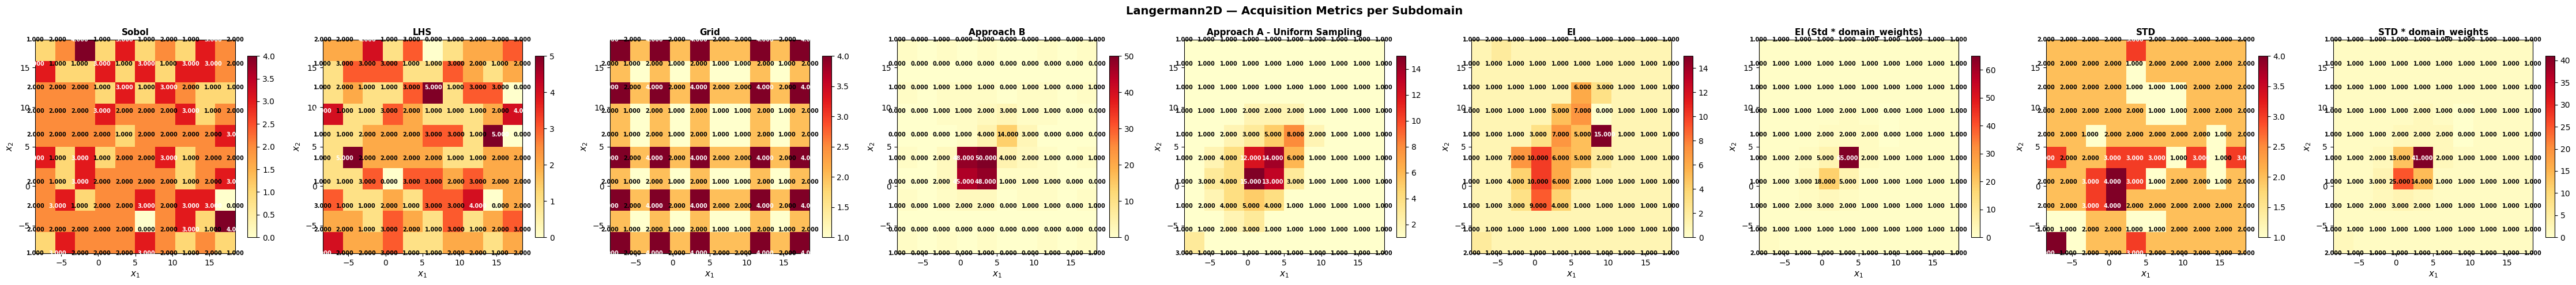

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec

# ======================================================================
# Figure 1: 3D Surface — Function + Envelopes (one per split config)
# ======================================================================
def plot_2d_envelopes_3d(f2d, domains, func_name, save_path=None):
    fig = plt.figure(figsize=(18, 6))

    for idx, (label, alpha_env) in enumerate([
        ('Original Function', None),
        ('Convex Underestimator $f^{\\mathrm{cvx}}$', 'lower'),
        ('Concave Overestimator $f^{\\mathrm{ccv}}$', 'upper'),
    ]):
        ax = fig.add_subplot(1, 3, idx + 1, projection='3d')

        for domain in domains:
            a1, b1, a2, b2 = domain
            xs, lower, upper, gap = f2d.envelope_interval(a1, b1, a2, b2)
            x1, x2 = xs[:, 0], xs[:, 1]
            orig = np.array([f2d.f(pt) for pt in xs])

            n = int(np.sqrt(xs.shape[0]))
            x1_g = x1.reshape(n, n)
            x2_g = x2.reshape(n, n)
            orig_g = orig.reshape(n, n)
            lower_g = lower.reshape(n, n)
            upper_g = upper.reshape(n, n)

            if alpha_env is None:
                ax.plot_surface(x1_g, x2_g, orig_g, cmap='viridis', alpha=0.8,
                                edgecolor='none')
            elif alpha_env == 'lower':
                ax.plot_surface(x1_g, x2_g, orig_g, cmap='viridis', alpha=0.3,
                                edgecolor='none')
                ax.plot_surface(x1_g, x2_g, lower_g, cmap='Blues', alpha=0.6,
                                edgecolor='none')
            elif alpha_env == 'upper':
                ax.plot_surface(x1_g, x2_g, orig_g, cmap='viridis', alpha=0.3,
                                edgecolor='none')
                ax.plot_surface(x1_g, x2_g, upper_g, cmap='Reds', alpha=0.6,
                                edgecolor='none')

        ax.set_xlabel('$x_1$', fontsize=11)
        ax.set_ylabel('$x_2$', fontsize=11)
        ax.set_zlabel('$f(x)$', fontsize=11)
        ax.set_title(label, fontsize=12, fontweight='bold')
        ax.view_init(elev=30, azim=-45)

    fig.suptitle(f'{func_name} — 3D Surface with McCormick Envelopes',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()


# ======================================================================
# Figure 2: Contour plots — Function, Lower, Upper, Gap (2x2 grid)
# ======================================================================
def plot_2d_envelopes_contour(f2d, domains, func_name, save_path=None):
    # Collect all data across domains
    all_x1, all_x2, all_orig, all_lower, all_upper, all_gap = [], [], [], [], [], []

    for domain in domains:
        a1, b1, a2, b2 = domain
        xs, lower, upper, gap = f2d.envelope_interval(a1, b1, a2, b2)
        all_x1.append(xs[:, 0])
        all_x2.append(xs[:, 1])
        all_orig.append(np.array([f2d.f(pt) for pt in xs]))
        all_lower.append(lower)
        all_upper.append(upper)
        all_gap.append(gap)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    titles = [
        'Original Function $f(x)$',
        'Convex Underestimator $f^{\\mathrm{cvx}}$',
        'Concave Overestimator $f^{\\mathrm{ccv}}$',
        'Relaxation Gap ($f^{\\mathrm{ccv}} - f^{\\mathrm{cvx}}$)'
    ]
    cmaps = ['viridis', 'Blues', 'Reds', 'hot']
    data_keys = [all_orig, all_lower, all_upper, all_gap]

    for ax_idx, (ax, title, cmap, data_list) in enumerate(
            zip(axes.ravel(), titles, cmaps, data_keys)):

        for d_idx, domain in enumerate(domains):
            a1, b1, a2, b2 = domain
            x1 = all_x1[d_idx]
            x2 = all_x2[d_idx]
            z = data_list[d_idx]

            n = int(np.sqrt(len(x1)))
            x1_g = x1.reshape(n, n)
            x2_g = x2.reshape(n, n)
            z_g = z.reshape(n, n)

            cf = ax.contourf(x1_g, x2_g, z_g, levels=30, cmap=cmap, alpha=0.85)

            # Draw subdomain boundaries
            ax.plot([a1, b1, b1, a1, a1], [a2, a2, b2, b2, a2],
                    'k--', lw=0.8, alpha=0.5)

        plt.colorbar(cf, ax=ax, shrink=0.85)
        ax.set_xlabel('$x_1$', fontsize=11)
        ax.set_ylabel('$x_2$', fontsize=11)
        ax.set_title(title, fontsize=12, fontweight='bold')

    fig.suptitle(f'{func_name} — Contour Views of McCormick Envelopes',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()


# ======================================================================
# Figure 3: Gap tightening with increasing splits (like the 1D version)
# ======================================================================
def plot_2d_gap_tightening(f2d, DOMAIN_2D, splits_list, func_name, save_path=None):
    n_splits = len(splits_list)
    fig, axes = plt.subplots(1, n_splits, figsize=(5 * n_splits, 5))

    if n_splits == 1:
        axes = [axes]

    for col, n_split in enumerate(splits_list):
        ax = axes[col]

        # Build subdomains for this split count
        x1_bounds = np.linspace(DOMAIN_2D[0], DOMAIN_2D[1], n_split + 1)
        x2_bounds = np.linspace(DOMAIN_2D[2], DOMAIN_2D[3], n_split + 1)

        # Collect gap across all subdomains
        all_x1, all_x2, all_gap = [], [], []
        for i in range(n_split):
            for j in range(n_split):
                a1, b1 = x1_bounds[i], x1_bounds[i + 1]
                a2, b2 = x2_bounds[j], x2_bounds[j + 1]
                xs, lower, upper, gap = f2d.envelope_interval(a1, b1, a2, b2)
                all_x1.append(xs[:, 0])
                all_x2.append(xs[:, 1])
                all_gap.append(gap)

        # Plot gap as filled contour per subdomain
        for x1, x2, gap in zip(all_x1, all_x2, all_gap):
            n = int(np.sqrt(len(x1)))
            x1_g = x1.reshape(n, n)
            x2_g = x2.reshape(n, n)
            gap_g = gap.reshape(n, n)
            cf = ax.contourf(x1_g, x2_g, gap_g, levels=30, cmap='hot', alpha=0.85)

        # Draw subdomain grid
        for b in x1_bounds:
            ax.axvline(b, color='white', ls='--', lw=0.8, alpha=0.7)
        for b in x2_bounds:
            ax.axhline(b, color='white', ls='--', lw=0.8, alpha=0.7)

        max_gap = max(g.max() for g in all_gap)
        mean_gap = np.mean([g.mean() for g in all_gap])

        ax.set_title(f'Splits = {n_split}×{n_split}\n'
                     f'max gap = {max_gap:.3f}, mean = {mean_gap:.3f}',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('$x_1$', fontsize=11)
        if col == 0:
            ax.set_ylabel('$x_2$', fontsize=11)

        plt.colorbar(cf, ax=ax, shrink=0.85, label='Gap')

    fig.suptitle(f'{func_name} — Relaxation Gap Tightening (2D)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()


# ======================================================================
# Figure 4: Metric bars as 2D heatmap per subdomain
# ======================================================================
def plot_2d_metrics_heatmap(df, func_name, save_path=None):
#     metrics = ['EI', 'EI (Std * domain_weights) ', 'STD', 'STD * domain_weights']
    metrics = ['Sobol', 'LHS', 'Grid',
       'Approach B', 'Approach A - Uniform Sampling', 'EI',
       'EI (Std * domain_weights)', 'STD', 'STD * domain_weights']
    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 5))

    for ax, metric in zip(axes, metrics):
        x_centers = sorted(df['x_center'].unique())
        y_centers = sorted(df['y_center'].unique())
        nx, ny = len(x_centers), len(y_centers)

        grid = np.zeros((ny, nx))
        for _, row in df.iterrows():
            xi = x_centers.index(row['x_center'])
            yi = y_centers.index(row['y_center'])
            grid[yi, xi] = row[metric]

        im = ax.imshow(grid, origin='lower', cmap='YlOrRd', aspect='auto',
                       extent=[min(x_centers), max(x_centers),
                               min(y_centers), max(y_centers)])

        # Annotate cells
        for _, row in df.iterrows():
            ax.text(row['x_center'], row['y_center'], f'{row[metric]:.3f}',
                    ha='center', va='center', fontsize=7,
                    color='black' if row[metric] < grid.max() * 0.7 else 'white',
                    fontweight='bold')

        plt.colorbar(im, ax=ax, shrink=0.85)
        ax.set_xlabel('$x_1$', fontsize=11)
        ax.set_ylabel('$x_2$', fontsize=11)
        ax.set_title(metric.strip(), fontsize=11, fontweight='bold')

    fig.suptitle(f'{func_name} — Acquisition Metrics per Subdomain',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()


def plot_2d_gap_tightening(f2d, DOMAIN_2D, splits_list, func_name, save_path=None):
    n_splits = len(splits_list)
    fig, axes = plt.subplots(1, n_splits, figsize=(5 * n_splits, 5))

    if n_splits == 1:
        axes = [axes]

    for col, n_split in enumerate(splits_list):
        ax = axes[col]

        # Build subdomains for this split count
        x1_bounds = np.linspace(DOMAIN_2D[0], DOMAIN_2D[1], n_split + 1)
        x2_bounds = np.linspace(DOMAIN_2D[2], DOMAIN_2D[3], n_split + 1)

        # Collect gap across all subdomains
        all_x1, all_x2, all_gap = [], [], []
        for i in range(n_split):
            for j in range(n_split):
                a1, b1 = x1_bounds[i], x1_bounds[i + 1]
                a2, b2 = x2_bounds[j], x2_bounds[j + 1]
                xs, lower, upper, gap = f2d.envelope_interval(a1, b1, a2, b2)
                all_x1.append(xs[:, 0])
                all_x2.append(xs[:, 1])
                all_gap.append(gap)

        # Calculate global min/max for consistent colorbar
        vmin = min(g.min() for g in all_gap)
        vmax = max(g.max() for g in all_gap)

        # Plot gap as filled contour per subdomain with consistent color scale
        for x1, x2, gap in zip(all_x1, all_x2, all_gap):
            n = int(np.sqrt(len(x1)))
            x1_g = x1.reshape(n, n)
            x2_g = x2.reshape(n, n)
            gap_g = gap.reshape(n, n)
            cf = ax.contourf(x1_g, x2_g, gap_g, levels=30, cmap='hot', 
                           vmin=vmin, vmax=vmax, alpha=0.85)

        # Draw subdomain grid
        for b in x1_bounds:
            ax.axvline(b, color='white', ls='--', lw=0.8, alpha=0.7)
        for b in x2_bounds:
            ax.axhline(b, color='white', ls='--', lw=0.8, alpha=0.7)

        max_gap = vmax
        mean_gap = np.mean([g.mean() for g in all_gap])

        ax.set_title(f'Splits = {n_split}×{n_split}\n'
                     f'max gap = {max_gap:.3f}, mean = {mean_gap:.3f}',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('$x_1$', fontsize=11)
        if col == 0:
            ax.set_ylabel('$x_2$', fontsize=11)

        plt.colorbar(cf, ax=ax, shrink=0.85, label='Gap')

    fig.suptitle(f'{func_name} — Relaxation Gap HeatMaps (2D)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()

def plot_2d_envelopes_contour(f2d, domains, func_name, save_path=None):
    # Collect all data across domains
    all_x1, all_x2, all_orig, all_lower, all_upper, all_gap = [], [], [], [], [], []

    for domain in domains:
        a1, b1, a2, b2 = domain
        xs, lower, upper, gap = f2d.envelope_interval(a1, b1, a2, b2)
        all_x1.append(xs[:, 0])
        all_x2.append(xs[:, 1])
        all_orig.append(np.array([f2d.f(pt) for pt in xs]))
        all_lower.append(lower)
        all_upper.append(upper)
        all_gap.append(gap)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    titles = [
        'Original Function $f(x)$',
        'Convex Underestimator $f^{\\mathrm{cvx}}$',
        'Concave Overestimator $f^{\\mathrm{ccv}}$',
        'Relaxation Gap ($f^{\\mathrm{ccv}} - f^{\\mathrm{cvx}}$)'
    ]
    cmaps = ['viridis', 'Blues', 'Reds', 'hot']
    data_keys = [all_orig, all_lower, all_upper, all_gap]

    for ax_idx, (ax, title, cmap, data_list) in enumerate(
            zip(axes.ravel(), titles, cmaps, data_keys)):

        # Calculate global min/max for consistent color scale
        vmin = min(z.min() for z in data_list)
        vmax = max(z.max() for z in data_list)

        for d_idx, domain in enumerate(domains):
            a1, b1, a2, b2 = domain
            x1 = all_x1[d_idx]
            x2 = all_x2[d_idx]
            z = data_list[d_idx]

            n = int(np.sqrt(len(x1)))
            x1_g = x1.reshape(n, n)
            x2_g = x2.reshape(n, n)
            z_g = z.reshape(n, n)

            cf = ax.contourf(x1_g, x2_g, z_g, levels=30, cmap=cmap, 
                           vmin=vmin, vmax=vmax, alpha=0.85)

            # Draw subdomain boundaries
            ax.plot([a1, b1, b1, a1, a1], [a2, a2, b2, b2, a2],
                    'k--', lw=0.8, alpha=0.5)

        plt.colorbar(cf, ax=ax, shrink=0.85)
        ax.set_xlabel('$x_1$', fontsize=11)
        ax.set_ylabel('$x_2$', fontsize=11)
        ax.set_title(title, fontsize=12, fontweight='bold')

    fig.suptitle(f'{func_name} — Contour Views of McCormick Envelopes',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
   
    
# ======================================================================
# Generate all figures
# ======================================================================
save_dir = '/Users/qazi/RWTH/Thesis2/presentation/plots/gap_analysis_2D'
os.makedirs(save_dir, exist_ok=True)

func_name = 'Langermann2D'

# Fig 1: 3D surfaces
plot_2d_envelopes_3d(f2d, domains, func_name,
    save_path=f'{save_dir}/{func_name}_2d_envelopes_3d.png')

# Fig 2: Contour views
plot_2d_envelopes_contour(f2d, domains, func_name,
    save_path=f'{save_dir}/{func_name}_2d_contour_envelopes.png')

# Fig 3: Gap tightening across splits
DOMAIN_2D = [domains[0][0], domains[-1][1], domains[0][2], domains[-1][3]]
plot_2d_gap_tightening(f2d, DOMAIN_2D, [5, 7, 10], func_name,
    save_path=f'{save_dir}/{func_name}_2d_gap_tightening.png')

Fig 4: Metric heatmaps
df["x_center"] = (df["x_min"] + df["x_max"]) / 2
df["y_center"] = (df["y_min"] + df["y_max"]) / 2
plot_2d_metrics_heatmap(df, func_name,
    save_path=f'{save_dir}/{func_name}_2d_metrics_heatmap.png')

/var/folders/c3/1z16953x2r900q_snc40rgjc0000gn/T/ipykernel_42934/3465741938.py:88: DeprecationWarning:

Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.



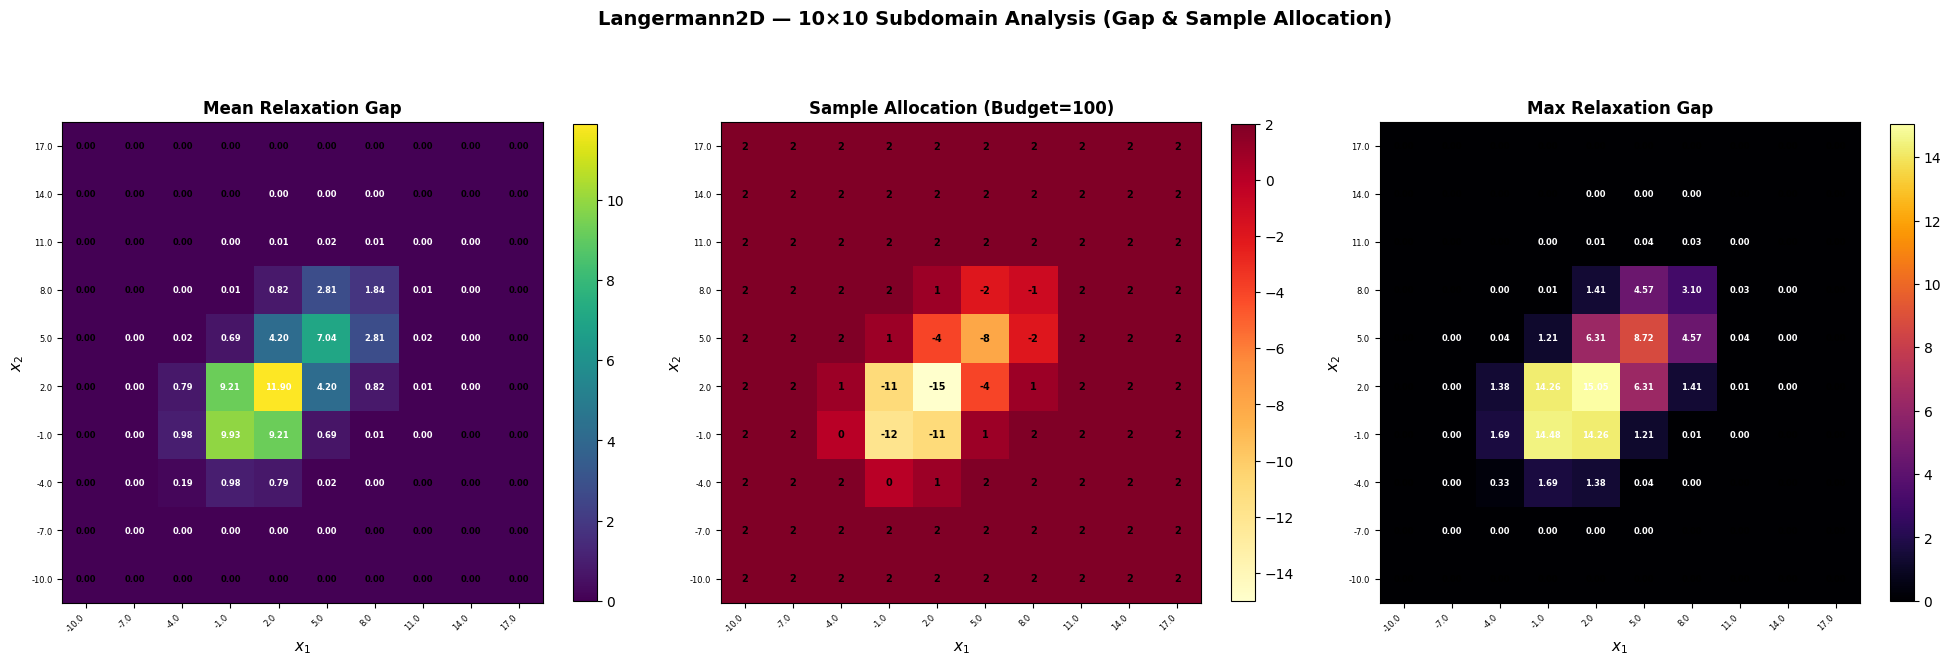

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm


def plot_sample_allocation_heatmap_10x10(f2d, DOMAIN_2D, func_name,
                                          n_split=10, save_path=None):
    """
    10x10 spatial heatmap showing sample allocation and gap per subdomain.
    """
    x1_lo, x1_hi, x2_lo, x2_hi = DOMAIN_2D
    x1_bounds = np.linspace(x1_lo, x1_hi, n_split + 1)
    x2_bounds = np.linspace(x2_lo, x2_hi, n_split + 1)

    gap_grid = np.zeros((n_split, n_split))
    max_gap_grid = np.zeros((n_split, n_split))

    for i in range(n_split):
        for j in range(n_split):
            a1, b1 = x1_bounds[i], x1_bounds[i + 1]
            a2, b2 = x2_bounds[j], x2_bounds[j + 1]
            _, lower, upper, gap = f2d.envelope_interval(a1, b1, a2, b2)
            gap_grid[j, i] = gap.mean()
            max_gap_grid[j, i] = gap.max()

    # Allocate samples proportional to gap (normalize)
    total_budget = 100  # adjust as needed
    min_samples = 2
    gap_flat = gap_grid.ravel()
    gap_normalized = gap_flat / gap_flat.sum() if gap_flat.sum() > 0 else np.ones_like(gap_flat)
    raw_allocation = gap_normalized * (total_budget - min_samples * n_split * n_split)
    allocation = np.floor(raw_allocation).astype(int) + min_samples

    # Distribute remaining budget
    remaining = total_budget - allocation.sum()
    if remaining > 0:
        residuals = raw_allocation - np.floor(raw_allocation)
        top_indices = np.argsort(residuals)[::-1][:remaining]
        allocation[top_indices] += 1

    sample_grid = allocation.reshape(n_split, n_split)

    # ---- Plot ----
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    # --- Panel 1: Mean Gap ---
    ax = axes[0]
    im1 = ax.imshow(gap_grid, origin='lower', cmap='viridis', aspect='equal')
    for i in range(n_split):
        for j in range(n_split):
            val = gap_grid[j, i]
            text_color = 'white' if val > np.median(gap_grid) else 'black'
            ax.text(i, j, f'{val:.2f}', ha='center', va='center',
                    fontsize=6, fontweight='bold', color=text_color)
    x_labels = [f'{x1_bounds[i]:.1f}' for i in range(n_split)]
    y_labels = [f'{x2_bounds[j]:.1f}' for j in range(n_split)]
    ax.set_xticks(range(n_split))
    ax.set_xticklabels(x_labels, fontsize=6, rotation=45, ha='right')
    ax.set_yticks(range(n_split))
    ax.set_yticklabels(y_labels, fontsize=6)
    ax.set_xlabel('$x_1$', fontsize=11)
    ax.set_ylabel('$x_2$', fontsize=11)
    ax.set_title('Mean Relaxation Gap', fontsize=12, fontweight='bold')
    plt.colorbar(im1, ax=ax, shrink=0.75)

    # --- Panel 2: Sample Allocation ---
    ax = axes[1]
    im2 = ax.imshow(sample_grid, origin='lower', cmap='YlOrRd', aspect='equal')
    for i in range(n_split):
        for j in range(n_split):
            val = sample_grid[j, i]
            text_color = 'white' if val > np.median(sample_grid) else 'black'
            ax.text(i, j, f'{val}', ha='center', va='center',
                    fontsize=7, fontweight='bold', color=text_color)
    ax.set_xticks(range(n_split))
    ax.set_xticklabels(x_labels, fontsize=6, rotation=45, ha='right')
    ax.set_yticks(range(n_split))
    ax.set_yticklabels(y_labels, fontsize=6)
    ax.set_xlabel('$x_1$', fontsize=11)
    ax.set_ylabel('$x_2$', fontsize=11)
    ax.set_title(f'Sample Allocation (Budget={total_budget})', fontsize=12, fontweight='bold')
    plt.colorbar(im2, ax=ax, shrink=0.75)

    # --- Panel 3: Max Gap ---
    ax = axes[2]
    im3 = ax.imshow(max_gap_grid, origin='lower', cmap='inferno', aspect='equal')
    for i in range(n_split):
        for j in range(n_split):
            val = max_gap_grid[j, i]
            text_color = 'white' if val > np.median(max_gap_grid) else 'black'
            ax.text(i, j, f'{val:.2f}', ha='center', va='center',
                    fontsize=6, fontweight='bold', color=text_color)
    ax.set_xticks(range(n_split))
    ax.set_xticklabels(x_labels, fontsize=6, rotation=45, ha='right')
    ax.set_yticks(range(n_split))
    ax.set_yticklabels(y_labels, fontsize=6)
    ax.set_xlabel('$x_1$', fontsize=11)
    ax.set_ylabel('$x_2$', fontsize=11)
    ax.set_title('Max Relaxation Gap', fontsize=12, fontweight='bold')
    plt.colorbar(im3, ax=ax, shrink=0.75)

    fig.suptitle(f'{func_name} — 10×10 Subdomain Analysis (Gap & Sample Allocation)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()


# ======================================================================
# Alternative: If you already have df with sample counts from your method
# ======================================================================
def plot_sample_allocation_from_df(df, func_name, n_split=10, save_path=None):
    """
    Use actual allocation data from your dataframe.
    Expects df with columns: x_min, x_max, y_min, y_max, and metric columns.
    """
    x_mins = sorted(df['x_min'].unique())
    y_mins = sorted(df['y_min'].unique())
    nx, ny = len(x_mins), len(y_mins)

    # Determine which columns exist
    gap_col = None
    for col in ['gap', 'mean_gap', 'Gap', 'relaxation_gap']:
        if col in df.columns:
            gap_col = col
            break

    sample_col = None
    for col in ['n_samples', 'samples', 'sample_count', 'budget', 'allocation']:
        if col in df.columns:
            sample_col = col
            break

    metric_cols = [c for c in ['EI', 'STD', 'STD * domain_weights',
                                'EI (Std * domain_weights) '] if c in df.columns]

    n_panels = 1 + (1 if gap_col else 0) + len(metric_cols)
    fig, axes = plt.subplots(1, n_panels, figsize=(5.5 * n_panels, 6))
    if n_panels == 1:
        axes = [axes]

    panel_idx = 0

    # --- Gap heatmap ---
    if gap_col:
        ax = axes[panel_idx]
        grid = np.zeros((ny, nx))
        for _, row in df.iterrows():
            xi = x_mins.index(row['x_min'])
            yi = y_mins.index(row['y_min'])
            grid[yi, xi] = row[gap_col]

        im = ax.imshow(grid, origin='lower', cmap='viridis', aspect='equal')
        for i in range(nx):
            for j in range(ny):
                val = grid[j, i]
                tc = 'white' if val > np.median(grid) else 'black'
                ax.text(i, j, f'{val:.2f}', ha='center', va='center',
                        fontsize=6, fontweight='bold', color=tc)
        ax.set_xticks(range(nx))
        ax.set_xticklabels([f'{v:.1f}' for v in x_mins], fontsize=6, rotation=45)
        ax.set_yticks(range(ny))
        ax.set_yticklabels([f'{v:.1f}' for v in y_mins], fontsize=6)
        ax.set_title('Relaxation Gap', fontsize=11, fontweight='bold')
        ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
        plt.colorbar(im, ax=ax, shrink=0.75)
        panel_idx += 1

    # --- Sample allocation ---
    if sample_col:
        ax = axes[panel_idx]
        grid = np.zeros((ny, nx))
        for _, row in df.iterrows():
            xi = x_mins.index(row['x_min'])
            yi = y_mins.index(row['y_min'])
            grid[yi, xi] = row[sample_col]

        im = ax.imshow(grid, origin='lower', cmap='YlOrRd', aspect='equal')
        for i in range(nx):
            for j in range(ny):
                val = grid[j, i]
                tc = 'white' if val > np.median(grid) else 'black'
                ax.text(i, j, f'{int(val)}', ha='center', va='center',
                        fontsize=7, fontweight='bold', color=tc)
        ax.set_xticks(range(nx))
        ax.set_xticklabels([f'{v:.1f}' for v in x_mins], fontsize=6, rotation=45)
        ax.set_yticks(range(ny))
        ax.set_yticklabels([f'{v:.1f}' for v in y_mins], fontsize=6)
        ax.set_title(f'Sample Allocation', fontsize=11, fontweight='bold')
        ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
        plt.colorbar(im, ax=ax, shrink=0.75)
        panel_idx += 1

    # --- Metric heatmaps ---
    metric_cmaps = ['PuBu', 'Greens', 'Oranges', 'Purples']
    for m_idx, metric in enumerate(metric_cols):
        ax = axes[panel_idx]
        grid = np.zeros((ny, nx))
        for _, row in df.iterrows():
            xi = x_mins.index(row['x_min'])
            yi = y_mins.index(row['y_min'])
            grid[yi, xi] = row[metric]

        im = ax.imshow(grid, origin='lower', cmap=metric_cmaps[m_idx % len(metric_cmaps)],
                       aspect='equal')
        for i in range(nx):
            for j in range(ny):
                val = grid[j, i]
                tc = 'white' if val > np.median(grid) else 'black'
                ax.text(i, j, f'{val:.2f}', ha='center', va='center',
                        fontsize=5, fontweight='bold', color=tc)
        ax.set_xticks(range(nx))
        ax.set_xticklabels([f'{v:.1f}' for v in x_mins], fontsize=6, rotation=45)
        ax.set_yticks(range(ny))
        ax.set_yticklabels([f'{v:.1f}' for v in y_mins], fontsize=6)
        ax.set_title(metric.strip(), fontsize=11, fontweight='bold')
        ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
        plt.colorbar(im, ax=ax, shrink=0.75)
        panel_idx += 1

    fig.suptitle(f'{func_name} — 10×10 Subdomain Sample Allocation & Metrics',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()


# ======================================================================
# Run
# ======================================================================
save_dir = '/Users/qazi/RWTH/Thesis2/presentation/plots/gap_analysis_2D'
DOMAIN_2D = [domains[0][0], domains[-1][1], domains[0][2], domains[-1][3]]

# Option 1: Compute from envelope directly
plot_sample_allocation_heatmap_10x10(f2d, DOMAIN_2D, func_name, n_split=10,
    save_path=f'{save_dir}/{func_name}_2d_10x10_allocation.png')

# Option 2: Use your existing dataframe (if available)
# plot_sample_allocation_from_df(df, func_name, n_split=10,
#     save_path=f'{save_dir}/{func_name}_2d_10x10_allocation_df.png')

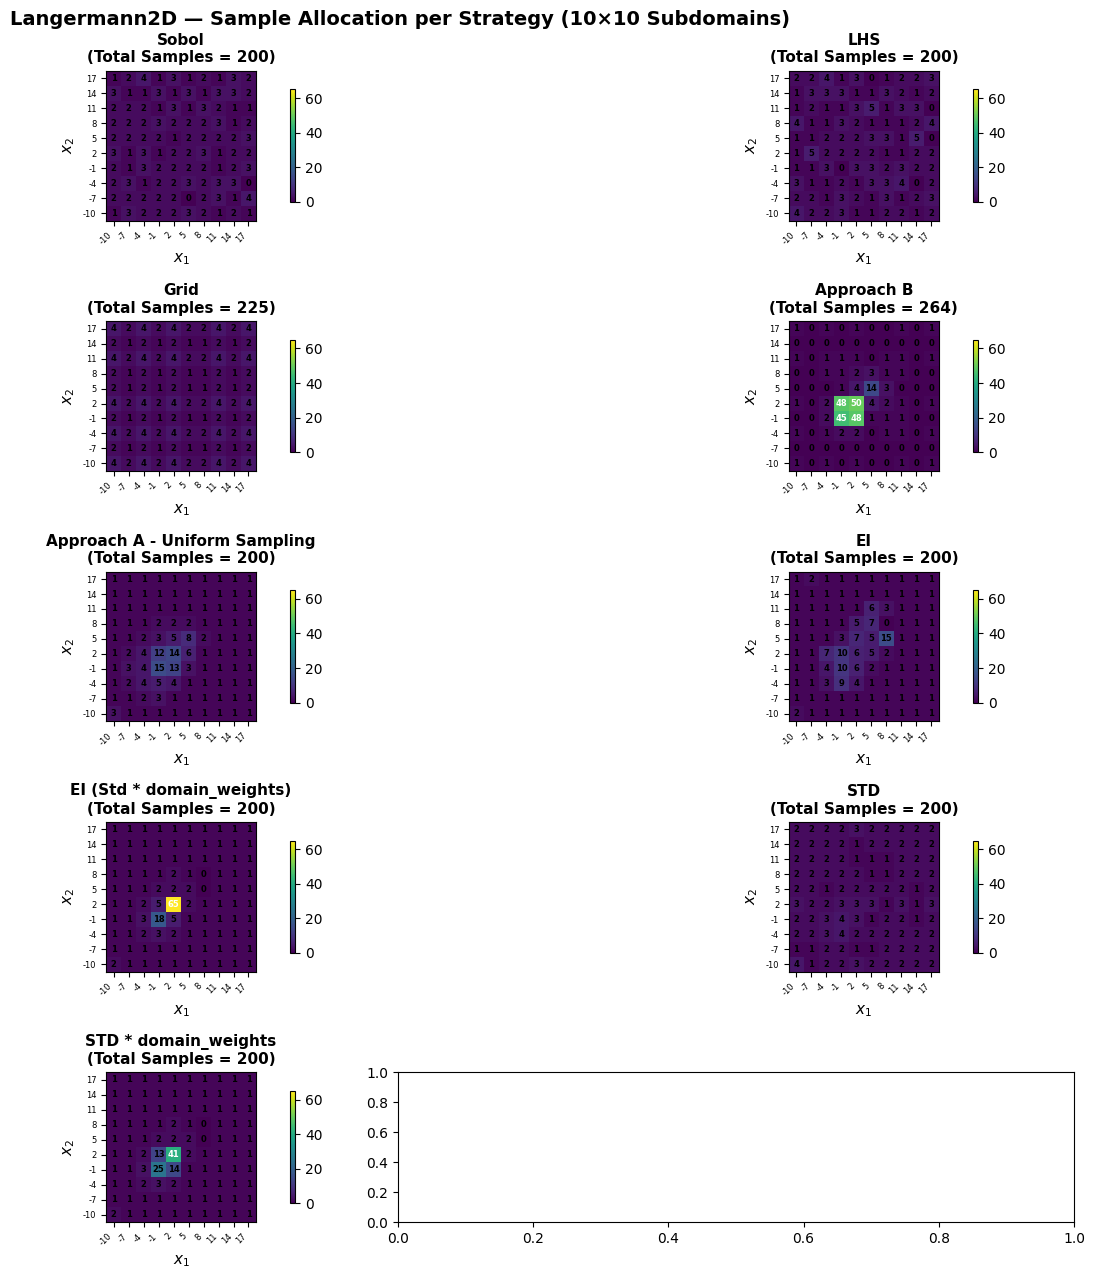

/var/folders/c3/1z16953x2r900q_snc40rgjc0000gn/T/ipykernel_42934/3465741938.py:88: DeprecationWarning:

Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.



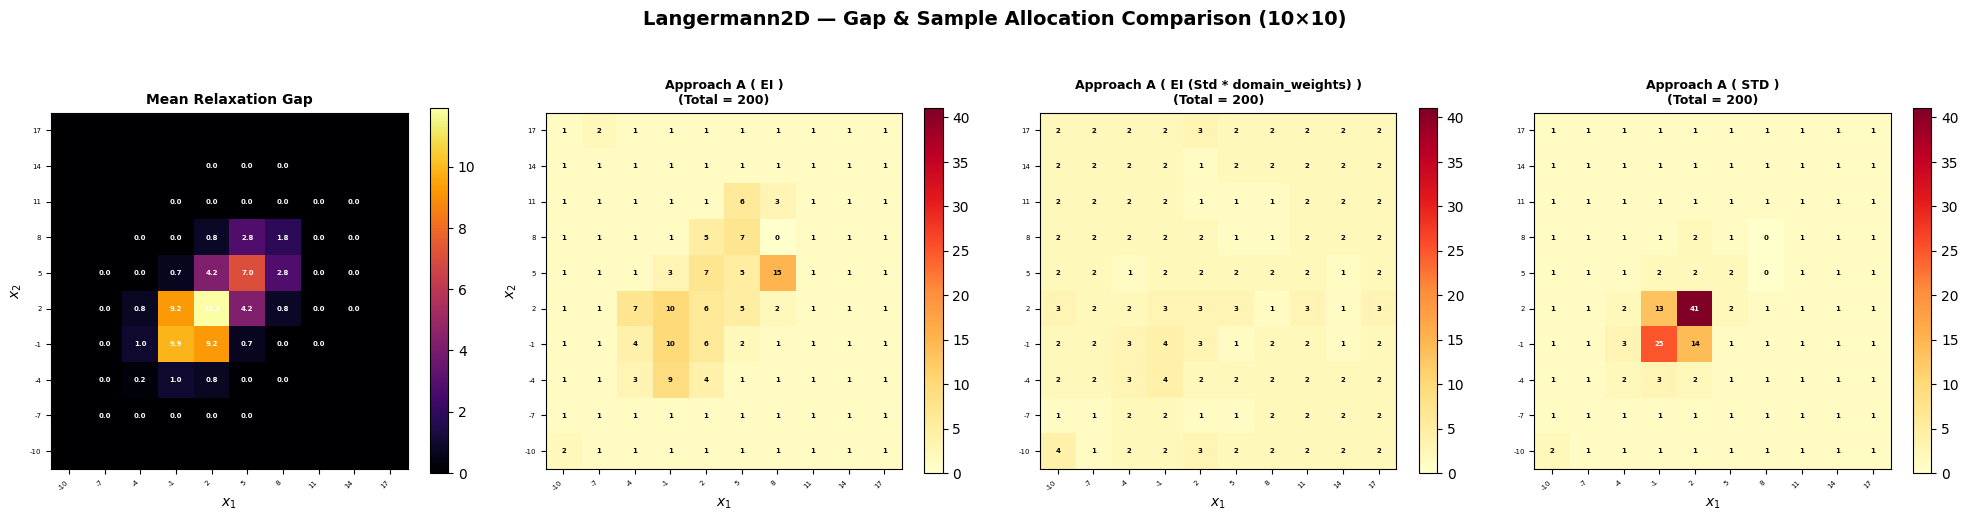

In [61]:
import numpy as np
import matplotlib.pyplot as plt


def plot_strategy_allocation_heatmaps(df, func_name, save_path=None):
    """
    One heatmap per strategy column showing sample allocation per subdomain.
    """
    # Domain boundaries
    x_vals = sorted(df['x_min'].unique())
    y_vals = sorted(df['y_min'].unique())
    nx, ny = len(x_vals), len(y_vals)

    strategy_cols = ['EI', 'EI (Std * domain_weights) ', 'STD', 'STD * domain_weights']
    strategy_cols = ['Sobol', 'LHS', 'Grid',
       'Approach B', 'Approach A - Uniform Sampling', 'EI',
       'EI (Std * domain_weights)', 'STD', 'STD * domain_weights']
    # Filter to columns that actually exist
    strategy_cols = [c for c in strategy_cols if c in df.columns]

    n = len(strategy_cols)
    fig, axes = plt.subplots(5, 2, figsize=(14, 13))
    axes = axes.ravel()

    # Shared color range
    global_min = min(df[c].min() for c in strategy_cols)
    global_max = max(df[c].max() for c in strategy_cols)

    for idx, strategy in enumerate(strategy_cols):
        ax = axes[idx]

        # Build 2D grid
        grid = np.full((ny, nx), np.nan)
        for _, row in df.iterrows():
            xi = x_vals.index(row['x_min'])
            yi = y_vals.index(row['y_min'])
            grid[yi, xi] = row[strategy]

        im = ax.imshow(grid, origin='lower', cmap='viridis',
                       vmin=global_min, vmax=global_max, aspect='equal')

        # Annotate each cell
        for i in range(nx):
            for j in range(ny):
                val = grid[j, i]
                if np.isnan(val):
                    continue
                tc = 'white' if val > (global_min + global_max) / 2 else 'black'
                ax.text(i, j, f'{int(val)}', ha='center', va='center',
                        fontsize=6, fontweight='bold', color=tc)

        ax.set_xticks(range(nx))
        ax.set_xticklabels([f'{v:.0f}' for v in x_vals], fontsize=6, rotation=45, ha='right')
        ax.set_yticks(range(ny))
        ax.set_yticklabels([f'{v:.0f}' for v in y_vals], fontsize=6)
        ax.set_xlabel('$x_1$', fontsize=11)
        ax.set_ylabel('$x_2$', fontsize=11)

        total = int(np.nansum(grid))
        ax.set_title(f'{strategy.strip()}\n(Total Samples = {total})',
                     fontsize=11, fontweight='bold')
        plt.colorbar(im, ax=ax, shrink=0.75)

    # Hide unused axes if < 4 strategies
    for idx in range(n, 4):
        axes[idx].set_visible(False)

    fig.suptitle(f'{func_name} — Sample Allocation per Strategy (10×10 Subdomains)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()


# ======================================================================
# Gap + all strategies in a single row (like your uploaded heatmap style)
# ======================================================================
def plot_gap_and_strategies_row(f2d, df, DOMAIN_2D, func_name, n_split=10, save_path=None):
    """
    Row of heatmaps: [Gap] [EI] [EI weighted] [STD] [STD weighted]
    """
    x1_lo, x1_hi, x2_lo, x2_hi = DOMAIN_2D
    x1_bounds = np.linspace(x1_lo, x1_hi, n_split + 1)
    x2_bounds = np.linspace(x2_lo, x2_hi, n_split + 1)

    # Compute gap
    gap_grid = np.zeros((n_split, n_split))
    for i in range(n_split):
        for j in range(n_split):
            a1, b1 = x1_bounds[i], x1_bounds[i + 1]
            a2, b2 = x2_bounds[j], x2_bounds[j + 1]
            _, lower, upper, gap = f2d.envelope_interval(a1, b1, a2, b2)
            gap_grid[j, i] = gap.mean()

    x_vals = sorted(df['x_min'].unique())
    y_vals = sorted(df['y_min'].unique())
    nx, ny = len(x_vals), len(y_vals)

    strategy_names = ['Approach A ( EI )', 'Approach A ( EI (Std * domain_weights) )', 'Approach A ( STD )', 'Approach A ( STD * domain_weights )']
    strategy_cols = ['EI', 'EI (Std * domain_weights) ', 'STD', 'STD * domain_weights']
    strategy_cols = [c for c in strategy_cols if c in df.columns]

    n_panels = 1 + len(strategy_cols)
    fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 5.5))

    # --- Panel 0: Gap ---
    ax = axes[0]
    im = ax.imshow(gap_grid, origin='lower', cmap='inferno', aspect='equal')
    for i in range(n_split):
        for j in range(n_split):
            val = gap_grid[j, i]
            tc = 'white' if val > np.median(gap_grid) else 'black'
            ax.text(i, j, f'{val:.1f}', ha='center', va='center',
                    fontsize=5, fontweight='bold', color=tc)
    ax.set_xticks(range(n_split))
    ax.set_xticklabels([f'{x1_bounds[i]:.0f}' for i in range(n_split)],
                       fontsize=5, rotation=45, ha='right')
    ax.set_yticks(range(n_split))
    ax.set_yticklabels([f'{x2_bounds[j]:.0f}' for j in range(n_split)], fontsize=5)
    ax.set_xlabel('$x_1$', fontsize=10)
    ax.set_ylabel('$x_2$', fontsize=10)
    ax.set_title('Mean Relaxation Gap', fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.75)

    # --- Strategy panels ---
    alloc_min = min(df[c].min() for c in strategy_cols)
    alloc_max = max(df[c].max() for c in strategy_cols)

    for s_idx, strategy in enumerate(strategy_cols):
        ax = axes[s_idx + 1]

        grid = np.full((ny, nx), np.nan)
        for _, row in df.iterrows():
            xi = x_vals.index(row['x_min'])
            yi = y_vals.index(row['y_min'])
            grid[yi, xi] = row[strategy]

        im = ax.imshow(grid, origin='lower', cmap='YlOrRd',
                       vmin=alloc_min, vmax=alloc_max, aspect='equal')

        for i in range(nx):
            for j in range(ny):
                val = grid[j, i]
                if np.isnan(val):
                    continue
                tc = 'white' if val > (alloc_min + alloc_max) / 2 else 'black'
                ax.text(i, j, f'{int(val)}', ha='center', va='center',
                        fontsize=5, fontweight='bold', color=tc)

        ax.set_xticks(range(nx))
        ax.set_xticklabels([f'{v:.0f}' for v in x_vals], fontsize=5, rotation=45, ha='right')
        ax.set_yticks(range(ny))
        ax.set_yticklabels([f'{v:.0f}' for v in y_vals], fontsize=5)
        ax.set_xlabel('$x_1$', fontsize=10)
        if s_idx == 0:
            ax.set_ylabel('$x_2$', fontsize=10)

        total = int(np.nansum(grid))
        ax.set_title(f'{strategy_names[s_idx].strip()}\n(Total = {total})',
                     fontsize=9, fontweight='bold')
        plt.colorbar(im, ax=ax, shrink=0.75)

    fig.suptitle(f'{func_name} — Gap & Sample Allocation Comparison (10×10)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()


# ======================================================================
# Run
# ======================================================================
save_dir = '/Users/qazi/RWTH/Thesis2/presentation/plots/gap_analysis_2D'
DOMAIN_2D = [domains[0][0], domains[-1][1], domains[0][2], domains[-1][3]]

# 2x2 grid of strategies
plot_strategy_allocation_heatmaps(df, func_name,
    save_path=f'{save_dir}/{func_name}_2d_strategy_heatmaps.png')

# Single row: gap + all strategies
plot_gap_and_strategies_row(f2d, df, DOMAIN_2D, func_name, n_split=10,
    save_path=f'{save_dir}/{func_name}_2d_gap_vs_strategies.png')